In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import html
import nlpaug.augmenter.word as naw
from nltk.stem import WordNetLemmatizer
import string
import nltk
import joblib
import torch
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,roc_curve
from collections import Counter

In [15]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [6]:
dataset=pd.read_csv("hate-speech-and-offensive-language.csv")
dataset

,count,hate_speech,offensive_language,neither,class,tweet
0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...
...,...,...,...,...,...,...
24778,3,0,2,1,1,you's a muthaf***in lie &#8220;@LifeAsKing: @2...
24779,3,0,1,2,2,"you've gone and broke the wrong heart baby, an..."
24780,3,0,3,0,1,young buck wanna eat!!.. dat nigguh like I ain...
24781,6,0,6,0,1,youu got wild bitches tellin you lies


In [7]:
# Mapping 0 and 1 to 1 (Toxic) and 2 to 0 (Non-Toxic)
dataset['Toxicity'] = dataset['class'].apply(lambda x: 0 if x ==2 else 1)
columns_to_drop = ['count', 'hate_speech', 'offensive_language', 'neither', 'class']
df = dataset.drop(columns=columns_to_drop, axis=1)
print(df.head())

                                               tweet  Toxicity
0  !!! RT @mayasolovely: As a woman you shouldn't...         0
1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...         1
2  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...         1
3  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...         1
4  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...         1


In [12]:
def light_clean_noise(text):
    text = str(text) # To handle non string inputs
    text = html.unescape(text) # Fix HTML encoding (e.g., change &amp; back to &)
    text = text.lower()  # Lowercasing
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Remove URLs
    text = re.sub(r'@\w+', '', text) #Remove User Mentions
    text = re.sub(r'#', '', text) # Remove Hastag symbol
    text = re.sub(r'\s+', ' ', text).strip() #Remove Extra Whitespace, newlines, and tabs
    text = re.sub(r'\brt\b', '', text, flags=re.IGNORECASE) # Remove rt  markers
    return text

df['light_cleaned_tweet'] = df['tweet'].apply(light_clean_noise)

In [9]:
# Initializing the augmenter for synonym replacement
aug = naw.SynonymAug(aug_src='wordnet')


minority_df = df[df['Toxicity'] == 0]
augmented_texts = []
for text in minority_df['light_cleaned_tweet']:
    augmented_text = aug.augment(text)
    augmented_texts.append(augmented_text[0])

df_augmented_data = pd.DataFrame({
    'light_cleaned_tweet': augmented_texts,
    'Toxicity': 0 })
#Combine with original data
df_augmented = pd.concat([df, df_augmented_data], axis=0).reset_index(drop=True)

print(f"Original size: {len(df)}")
print(f"New size after augmentation: {len(df_augmented)}")
print(df_augmented['Toxicity'].value_counts(normalize=True))

Original size: 24783
New size after augmentation: 28946
Toxicity
1    0.712361
0    0.287639
Name: proportion, dtype: float64


In [10]:
# Train test validation splitting
X = df_augmented['light_cleaned_tweet']
y = df_augmented['Toxicity']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

Train size: 20262
Validation size: 4342
Test size: 4342


In [17]:
# Preprocessing function for Logistic regression
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_lr(text):
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return " ".join(tokens)
    
# Preprocessing function for RoBERTa
def preprocess_roberta(text):
    return text.strip()    

In [18]:
# Applying the preprocessing
X_train_lr = X_train.apply(preprocess_lr)
X_val_lr   = X_val.apply(preprocess_lr)
X_test_lr  = X_test.apply(preprocess_lr)

X_train_rob = X_train.apply(preprocess_roberta)
X_val_rob   = X_val.apply(preprocess_roberta)
X_test_rob  = X_test.apply(preprocess_roberta)

In [19]:
# Logistic Regression Tokenization Using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train_lr)
X_val_tfidf = tfidf.transform(X_val_lr)
X_test_tfidf  = tfidf.transform(X_test_lr)

In [23]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, precision_recall_curve, auc

lr_model = joblib.load("./models/LR/logistic_regression_model.pkl")
vectorizer = joblib.load("./models/LR/tfidf_vectorizer.pkl")

model_path = "./models/RoBERTa/model2(Better)/" 
tokenizer = AutoTokenizer.from_pretrained(model_path)
ro_model = AutoModelForSequenceClassification.from_pretrained(model_path)
ro_model.eval()

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

In [28]:
def get_roberta_probs(texts, batch_size=16):
    all_probs = []
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    ro_model.to(device)
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
        with torch.no_grad():
            logits = ro_model(**inputs).logits
            probs = torch.softmax(logits, dim=1)
            all_probs.extend(probs[:, 1].cpu().tolist())
    return np.array(all_probs)

In [32]:
y_true = y_test.values 

# --- Logistic Regression Logic ---
X_test_transformed = vectorizer.transform(X_test_lr.tolist())
lr_probs = lr_model.predict_proba(X_test_transformed)[:, 1]
lr_threshold = 0.35
lr_preds = (lr_probs >= lr_threshold).astype(int)

# --- RoBERTa Logic ---
roberta_probs = get_roberta_probs(X_test_rob.tolist())
roberta_preds = (roberta_probs > 0.5).astype(int)


In [34]:
print(f"--- RoBERTa Report ---")
print(classification_report(y_true, roberta_preds))

print(f"\n--- Logistic Regression Report (Tuned Threshold: {lr_threshold}) ---")
print(classification_report(y_true, lr_preds))

--- RoBERTa Report ---
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      1249
           1       0.98      0.98      0.98      3093

    accuracy                           0.97      4342
   macro avg       0.96      0.96      0.96      4342
weighted avg       0.97      0.97      0.97      4342


--- Logistic Regression Report (Tuned Threshold: 0.35) ---
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      1249
           1       0.98      0.96      0.97      3093

    accuracy                           0.95      4342
   macro avg       0.94      0.95      0.94      4342
weighted avg       0.95      0.95      0.95      4342



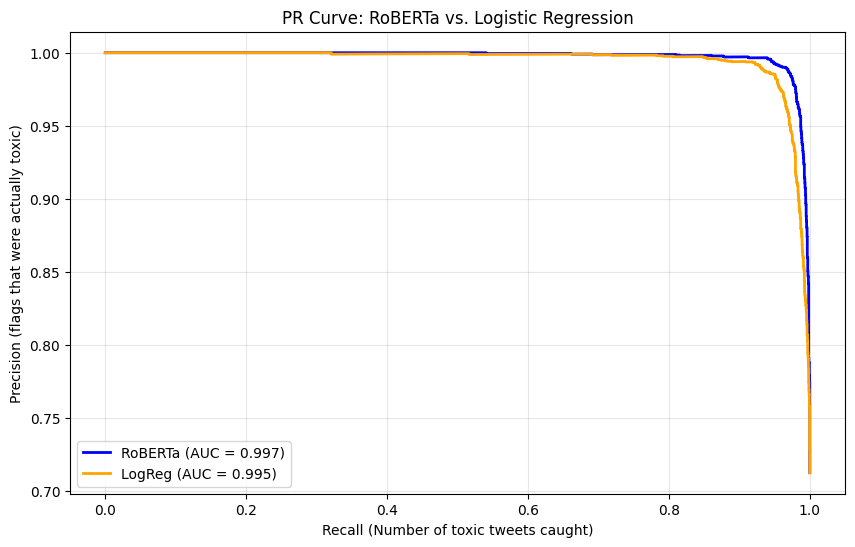

In [36]:
plt.figure(figsize=(10, 6))

for name, probs, color in [("RoBERTa", roberta_probs, "blue"), ("LogReg", lr_probs, "orange")]:
    precision, recall, thresholds = precision_recall_curve(y_true, probs)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{name} (AUC = {pr_auc:.3f})', color=color, lw=2)
    
    if name == "LogReg":
        # Find the index of the threshold closest to 0.35
        idx = np.argmin(np.abs(thresholds - lr_threshold))

plt.xlabel('Recall (Number of toxic tweets caught)')
plt.ylabel('Precision (flags that were actually toxic)')
plt.title('PR Curve: RoBERTa vs. Logistic Regression')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

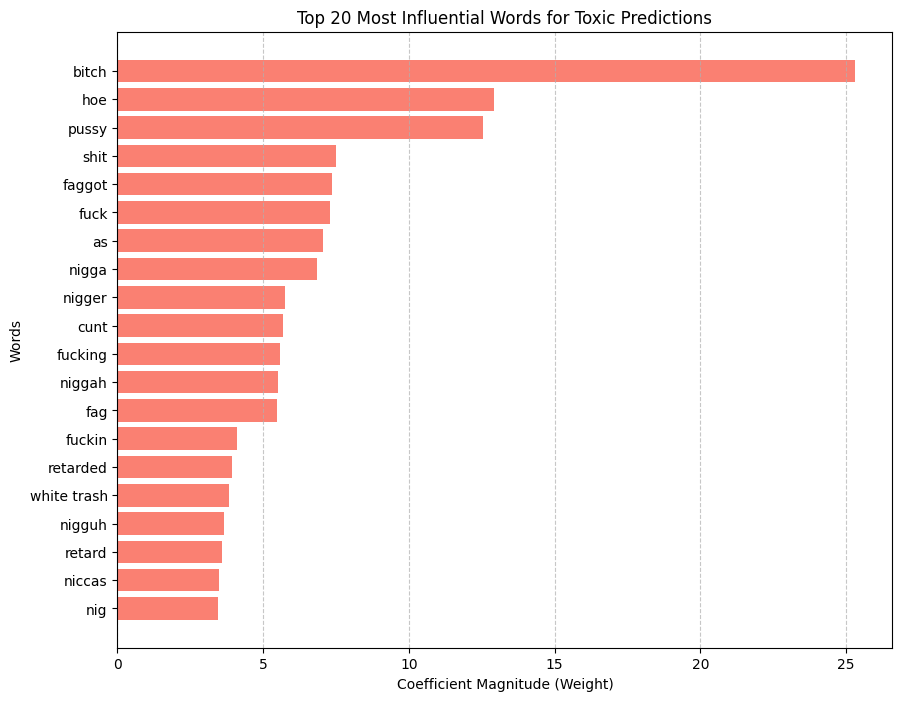

In [37]:
def plot_top_features(vectorizer, model, top_n=20):
    feature_names = vectorizer.get_feature_names_out()
    coefficients = model.coef_[0]
    
    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefficients
    })
    
    top_toxic = feature_importance.sort_values(by='Coefficient', ascending=False).head(top_n)
    
    # Plotting
    plt.figure(figsize=(10, 8))
    plt.barh(top_toxic['Feature'], top_toxic['Coefficient'], color='salmon')
    plt.gca().invert_yaxis()  # Put the highest at the top
    plt.xlabel('Coefficient Magnitude (Weight)')
    plt.ylabel('Words')
    plt.title(f'Top {top_n} Most Influential Words for Toxic Predictions')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()
    
    return top_toxic

top_words = plot_top_features(vectorizer, lr_model)

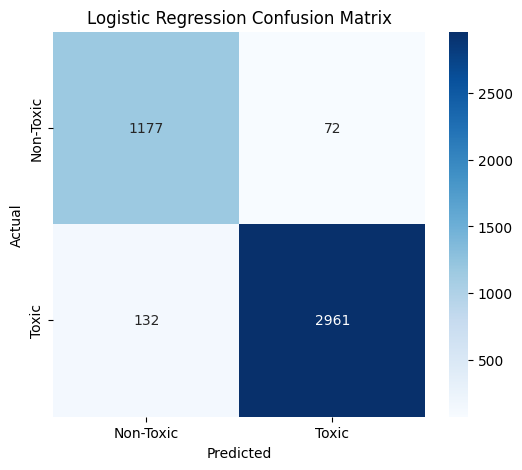

In [48]:
cm_lr = confusion_matrix(y_test, lr_preds)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Toxic", "Toxic"],
    yticklabels=["Non-Toxic", "Toxic"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()


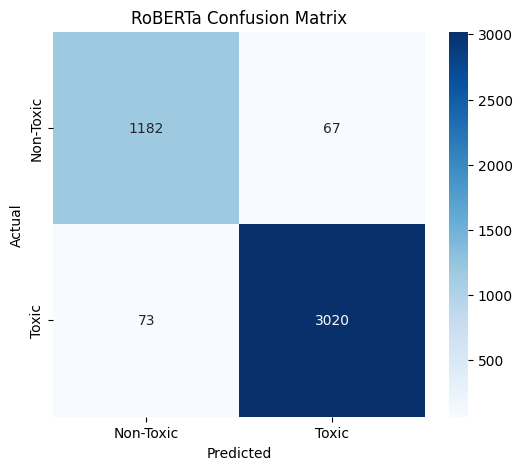

In [49]:
cm_ro = confusion_matrix(y_test, roberta_preds)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_ro,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Toxic", "Toxic"],
    yticklabels=["Non-Toxic", "Toxic"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("RoBERTa Confusion Matrix")
plt.show()


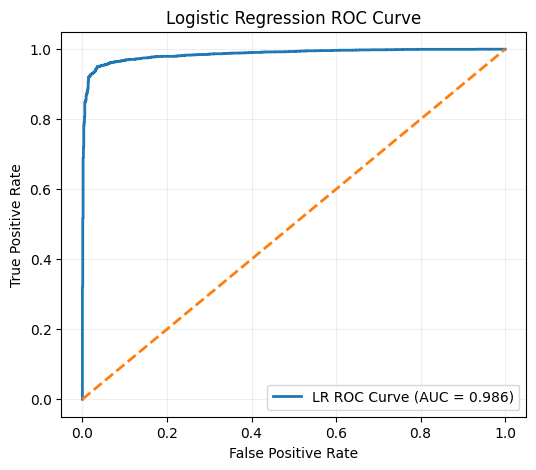

In [54]:
from sklearn.metrics import roc_curve, auc

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(6,5))
plt.plot(
    fpr_lr, tpr_lr,
    lw=2,
    label=f"LR ROC Curve (AUC = {roc_auc_lr:.3f})"
)
plt.plot([0,1], [0,1], linestyle="--", lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()


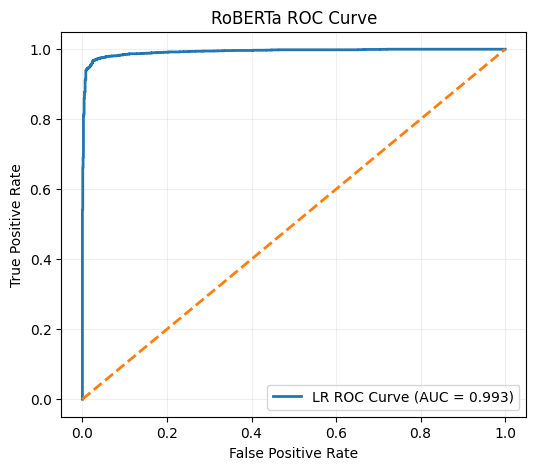

In [56]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, roberta_probs)
roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(6,5))
plt.plot(
    fpr_lr, tpr_lr,
    lw=2,
    label=f"LR ROC Curve (AUC = {roc_auc_lr:.3f})"
)
plt.plot([0,1], [0,1], linestyle="--", lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("RoBERTa ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()


In [38]:
def predict_toxicity_lr(text):
    text = light_clean_noise(text)
    text = preprocess_lr(text)
    vec = vectorizer.transform([text])
    prob = lr_model.predict_proba(vec)[0][1]
    pred = int(prob >= 0.35)
    
    return {
        "label": "Toxic" if pred == 1 else "Non-Toxic",
        "confidence": prob if pred == 1 else (1 - prob)
    }

In [39]:
def predict_toxicity_roberta(text):
    text = preprocess_roberta(text)
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )
    device = next(ro_model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    ro_model.eval()
    with torch.no_grad():
        outputs = ro_model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()

    return {
        "label": "Toxic" if pred == 1 else "Non-Toxic",
        "confidence": probs[0][pred].item()
    }

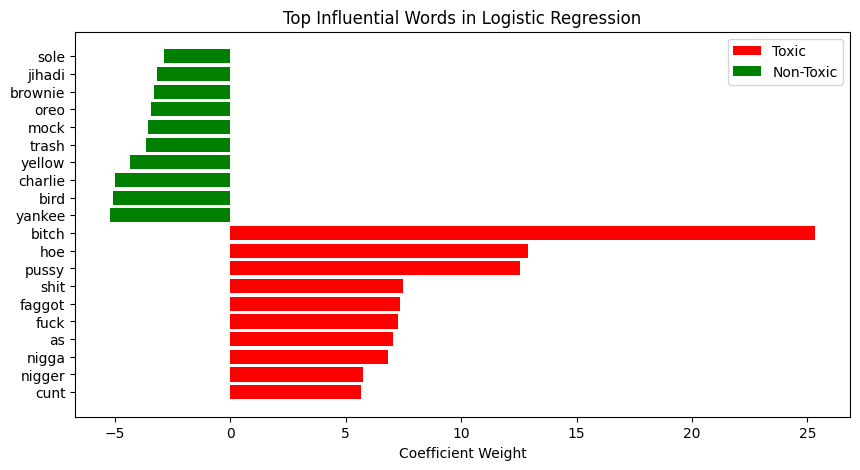

In [64]:
import numpy as np
import matplotlib.pyplot as plt

feature_names = vectorizer.get_feature_names_out()
coefficients = lr_model.coef_[0]

# Top toxic
top_pos_idx = np.argsort(coefficients)[-10:]
# Topm non-toxic
top_neg_idx = np.argsort(coefficients)[:10]

plt.figure(figsize=(10,5))

plt.barh(
    feature_names[top_pos_idx],
    coefficients[top_pos_idx],
    color="red",
    label="Toxic"
)
plt.barh(
    feature_names[top_neg_idx],
    coefficients[top_neg_idx],
    color="green",
    label="Non-Toxic"
)

plt.xlabel("Coefficient Weight")
plt.title("Top Influential Words in Logistic Regression")
plt.legend()
plt.show()


In [95]:
test_phrase = "you are a girl?"

lr_res = predict_toxicity_lr(test_phrase)
rb_res = predict_toxicity_roberta(test_phrase)
print(f"Input: {test_phrase}")
print(f"{'MODEL':<10} | {'PREDICTION':<12} | {'CONFIDENCE':<10}")
print("-" * 40)
print(f"{'LogReg':<10} | {lr_res['label']:<12} | {lr_res['confidence']:.2%}")
print(f"{'RoBERTa':<10} | {rb_res['label']:<12} | {rb_res['confidence']:.2%}")

Input: you are a girl?
MODEL      | PREDICTION   | CONFIDENCE
----------------------------------------
LogReg     | Toxic        | 56.39%
RoBERTa    | Non-Toxic    | 52.20%


In [89]:
test_phrase = "I strongly disagree with someone like you"

lr_res = predict_toxicity_lr(test_phrase)
rb_res = predict_toxicity_roberta(test_phrase)
print(f"Input: {test_phrase}")
print(f"{'MODEL':<10} | {'PREDICTION':<12} | {'CONFIDENCE':<10}")
print("-" * 40)
print(f"{'LogReg':<10} | {lr_res['label']:<12} | {lr_res['confidence']:.2%}")
print(f"{'RoBERTa':<10} | {rb_res['label']:<12} | {rb_res['confidence']:.2%}")

Input: I strongly disagree with someone like you
MODEL      | PREDICTION   | CONFIDENCE
----------------------------------------
LogReg     | Toxic        | 58.25%
RoBERTa    | Non-Toxic    | 98.69%


In [66]:
test_phrase = "Can you go SHIT yourself"

lr_res = predict_toxicity_lr(test_phrase)
rb_res = predict_toxicity_roberta(test_phrase)
print(f"Input: {test_phrase}")
print(f"{'MODEL':<10} | {'PREDICTION':<12} | {'CONFIDENCE':<10}")
print("-" * 40)
print(f"{'LogReg':<10} | {lr_res['label']:<12} | {lr_res['confidence']:.2%}")
print(f"{'RoBERTa':<10} | {rb_res['label']:<12} | {rb_res['confidence']:.2%}")

Input: Can you go SHIT yourself
MODEL      | PREDICTION   | CONFIDENCE
----------------------------------------
LogReg     | Toxic        | 99.82%
RoBERTa    | Toxic        | 99.84%
